# **Facial Expression Recognition System**

### import the dataset

In [29]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [30]:
# os is a python library that helps interact with all the files and the folders
import os

# listdir(path)- shows everything stored inside path
print(os.listdir(path))

#train - dataset we'll use to train the model
#test - dataset we use to check how correctly the model is working

['test', 'train']


### load the training images

In [31]:
# tensorflow is a python library that helps train a model
import tensorflow as tf


#keras - a part of tensor library that is a machine learning pipeline used to train models
#.utils - a utilities or a helper function
# image_dataset_from_library - make a image datset from the directory that tensorflow can use in model trainig

train_data = tf.keras.utils.image_dataset_from_directory(

    path + "/train",
    # go to train folder in the dataset stored in path

    image_size =(48,48),

    color_mode="grayscale",

    batch_size=32
)

Found 28709 files belonging to 7 classes.


### load the testing images

In [32]:
test_data = tf.keras.utils.image_dataset_from_directory(
    path + "/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32
)

Found 7178 files belonging to 7 classes.


In [33]:
# check the data

print(test_data.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### look at what's inside train data

In [34]:
for images , labels in train_data.take(1):
  print(images.shape)
  print(labels.shape)

(32, 48, 48, 1)
(32,)


### take 9 faces from our dataset and display themin a 3*3 grid with their emotions written above their faces

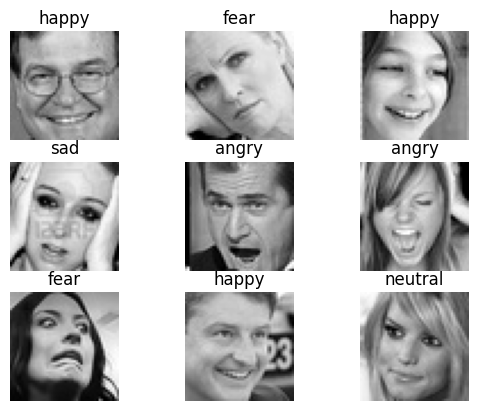

In [35]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.show()


### Normalise the numbers

In [36]:
# in grayscale the images are made of numbers ranging from 0 to 255 so we normalise it to make working easier
# we do not normalize the dataset we add a normalization layer through which every layer will go

normalisation_layer  = tf.keras.layers.Rescaling(1./255)

### CNN

In [37]:
# build an empty model using keras' sequential that makes a model layer by layer

model = tf.keras.Sequential()

In [38]:
# now we start filling the model

model.add(normalisation_layer)

# now an image enters so it becomes 48*48 then rescaling then value comes between 0-1 and then it is added to the model

In [39]:
# we use layers to access the kera layer Conv2D that is Convolutional Layer i.e. actual CNN
# in CNN model we add 32 filters ... suppose filter 1 will check the edge filter 2 will detect something else
# we do not fix the filters the model decides it itself while trainig
# the filters in our model are 32 and 3 rows 3 columns each filter format

model.add(tf.keras.layers.Conv2D(16, (3, 3), activation="relu"))

In [40]:
## Convo2D finds features so now we have huge imformation . to shorten it and keep the strongest parts we use MaxPooling

model.add(tf.keras.layers.MaxPooling2D((2,2)))

In [41]:
## add another Convo2D layer to see more complex features

model.add(tf.keras.layers.Conv2D(64,(3,3),activation="relu"))

In [42]:
## add another layer of maxpooling to keep the strongest features

model.add(tf.keras.layers.MaxPooling2D((2,2)))

In [43]:
## to convert the 2*2 grid of features created by convo2D and maxpooling to a single long list

model.add(tf.keras.layers.Flatten())

In [44]:
## now we connect features to figure out the emotion using dense

model.add(tf.keras.layers.Dense(128))

In [45]:
## we want final 7 emotions so we again use dense and we want output as probabilities of getting this particular emotion so we use softmax

model.add(tf.keras.layers.Dense(7,activation="softmax"))

In [46]:
## now we have made the model but still the model doesnt know how to learn yet so .compile the model
## optimizer-adam - the mistakes that the model makes during learning how can they be improved next time
## loss - how wrong did the model learn
## accuracy - how right did the model learn

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics =["accuracy"]
)

In [47]:
## train the model using model.fit . epochs goes though the data

history = model.fit(
    train_data,
    epochs=10,
    validation_data = test_data
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 99s 104ms/step - accuracy: 0.3913 - loss: 1.5801 - val_accuracy: 0.4583 - val_loss: 1.4330
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.4751 - loss: 1.3809 - val_accuracy: 0.4727 - val_loss: 1.3820
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5162 - loss: 1.2893 - val_accuracy: 0.4944 - val_loss: 1.3496
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.5478 - loss: 1.2086 - val_accuracy: 0.5045 - val_loss: 1.3395
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.5746 - loss: 1.1449 - val_accuracy: 0.4857 - val_loss: 1.4323
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.5958 - loss: 1.0870 - val_accuracy: 0.4962 - val_loss: 1.4508
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6136 - loss: 1.0376 - val_accuracy: 0.5013 - val_loss: 1.4184
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.6325 - loss: 0.9912 -

In [48]:
### evaluate the model

test_loss, test_accuracy = model.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4941 - loss: 1.5776


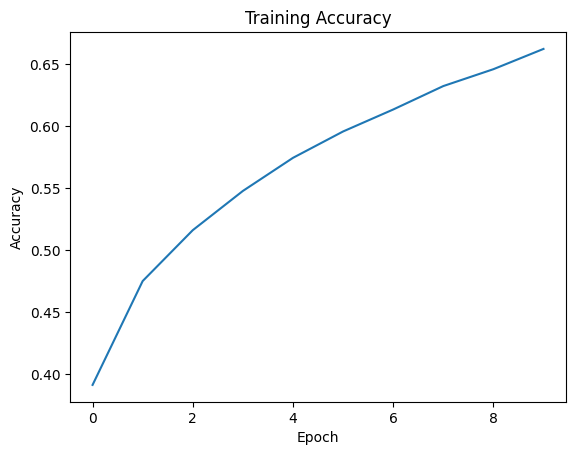

In [49]:
## plot the accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel('Accuracy')
plt.show()

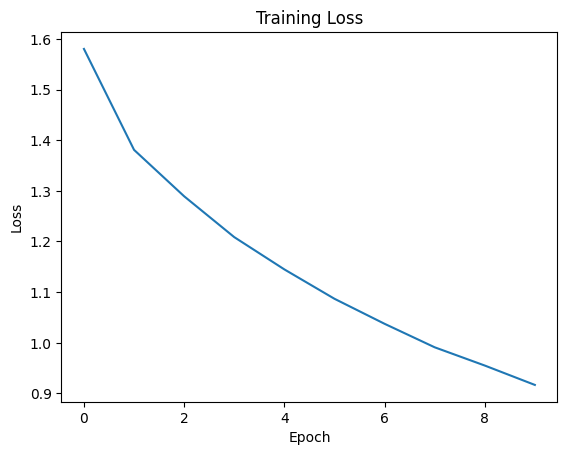

In [50]:
## loss graph

plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [51]:
## take one batch

for images,labels in test_data.take(1):
  image=images[0]
  label=labels[0]

In [52]:
## ask model to predict

prediction = model.predict(tf.expand_dims(image,axis=0))

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
[[3.3174172e-02 1.4086023e-06 6.4157307e-02 2.2141384e-03 1.2479879e-02
  2.7473332e-04 8.8769841e-01]]


In [53]:
predicted_class = tf.argmax(prediction[0]).numpy()
print("Predicted: ",test_data.class_names[predicted_class])

Predicted:  surprise


In [54]:
print("Actual:",test_data.class_names[label.numpy()])

Actual: surprise


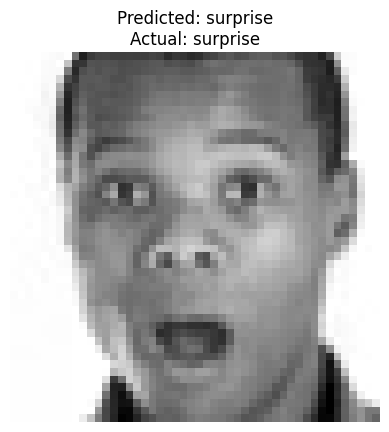

In [55]:
plt.imshow(image.numpy().squeeze(), cmap="gray")
plt.title(f"Predicted: {test_data.class_names[predicted_class]}\nActual: {test_data.class_names[label.numpy()]}")
plt.axis("off")
plt.show()

In [56]:
for images, labels in test_data.take(1):
  predictions=model.predict(images)

predicted_class= tf.argmax(predictions,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


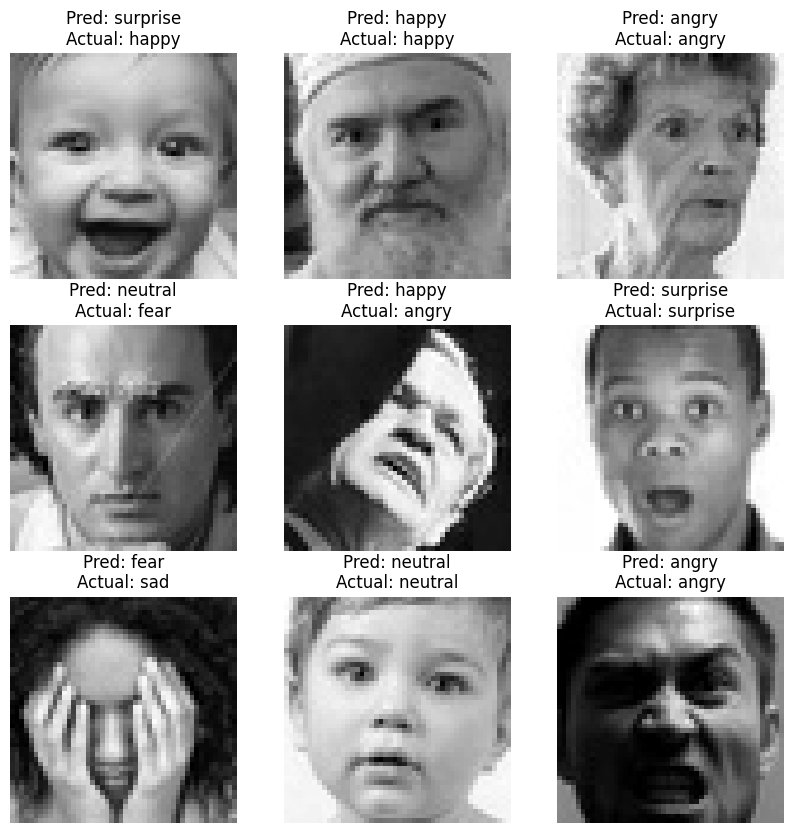

In [57]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")

    predicted = test_data.class_names[predicted_class[i]]
    actual = test_data.class_names[labels[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.show()

In [58]:
from re import VERBOSE
## lets make a confusion matrix to see where our model is getting the right predictions and where it is getting the wrong predictions

y_true=[]
y_pred=[]

for images,labels in test_data:
  predicted = model.predict(images,verbose=0)
  predicted_classes = tf.argmax(predicted,axis=1)

  y_true.extend(labels.numpy())
  y_pred.extend(predicted_classes.numpy())

In [59]:
## make the confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true,y_pred)
print(cm)

[[ 405   15  105  121  116  167   29]
 [  26   44   16    8    6    9    2]
 [ 165    9  338  101  127  203   81]
 [ 138    4   76 1252  143  113   48]
 [ 166    7   94  162  575  205   24]
 [ 226   16  183  135  214  440   33]
 [  63    3  128   61   50   33  493]]


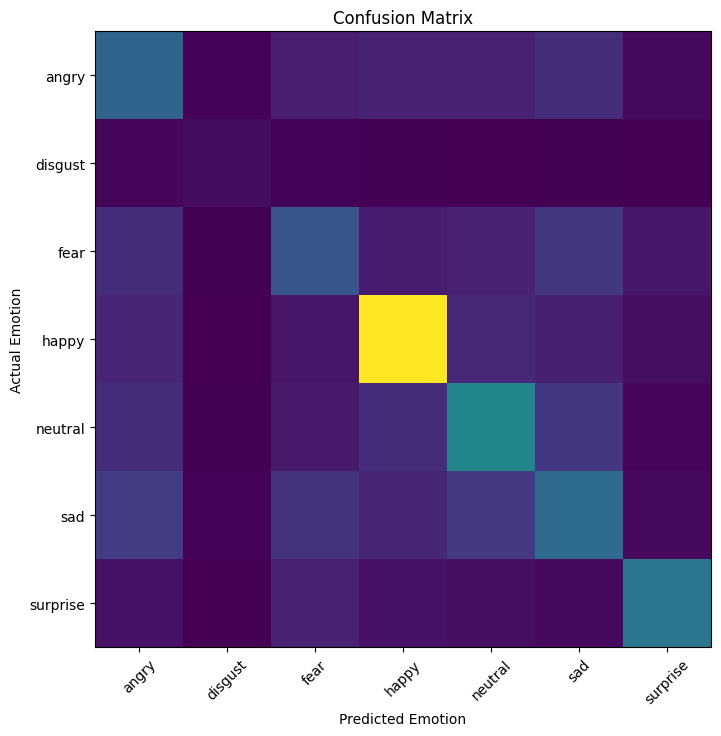

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cm)

plt.xticks(range(7), test_data.class_names, rotation=45)
plt.yticks(range(7), test_data.class_names)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix")

plt.show()

In [61]:
## save the model

model.save("Facial_epression_model.keras")

In [62]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

display(Javascript("""
async function takePhoto() {
  const div = document.createElement('div');

  const video = document.createElement('video');
  video.style.display = 'block';
  const stream = await navigator.mediaDevices.getUserMedia({video: true});

  document.body.appendChild(video);
  video.srcObject = stream;
  await video.play();

  google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

  await new Promise((resolve) => setTimeout(resolve, 3000));

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);

  stream.getVideoTracks()[0].stop();
  video.remove();

  return canvas.toDataURL('image/jpeg', 0.8);
}
"""))

photo = eval_js('takePhoto()')
image = b64decode(photo.split(',')[1])

with open('webcam.jpg', 'wb') as f:
    f.write(image)

print("Photo captured!")

<IPython.core.display.Javascript object>

Photo captured!


In [63]:
## make it live

!pip install mediapipe

In [64]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe Tasks loaded!")

MediaPipe Tasks loaded!


In [65]:
!rm -f face_detector.tflite

In [66]:
!rm -f face_detector.tflite

!wget -q -O face_detector.tflite \
"https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"

In [67]:

!ls -lh face_detector.tflite

-rw-r--r-- 1 root root 225K Apr 26  2023 face_detector.tflite


In [68]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
RunningMode = mp.tasks.vision.RunningMode

options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path="face_detector.tflite"),
    running_mode=RunningMode.IMAGE,
    min_detection_confidence=0.5
)

detector = FaceDetector.create_from_options(options)

print("Face detector ready!")

Face detector ready!


In [69]:
from mediapipe import Image

mp_image = Image.create_from_file("webcam.jpg")

result = detector.detect(mp_image)

print("Faces detected:", len(result.detections))

Faces detected: 1


In [70]:
from PIL import Image
import numpy as np

img = Image.open("webcam.jpg")
img_np = np.array(img)

detection = result.detections[0]
box = detection.bounding_box

x = box.origin_x
y = box.origin_y
w = box.width
h = box.height

face = img_np[y:y+h, x:x+w]

print("Face shape:", face.shape)

Face shape: (154, 202, 3)


In [71]:
from PIL import Image

face_image = Image.fromarray(face)

face_image = face_image.convert("L")
face_image = face_image.resize((48, 48))

face_array = np.array(face_image)

print("New shape:", face_array.shape)

New shape: (48, 48)


In [72]:
face_input = face_array / 255.0

face_input = np.expand_dims(face_input, axis=-1)
face_input = np.expand_dims(face_input, axis=0)

print("Input shape:", face_input.shape)

Input shape: (1, 48, 48, 1)


In [75]:
prediction = model.predict(face_input)

predicted_class = np.argmax(prediction[0])

print("Predicted emotion:", test_data.class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted emotion: angry
